# NG-SMR + HB ammonia NPV simulation

Run the Monte Carlo ammonia NPV model for NG-SMR + HB at 1,000,000 tNH3/year. The notebook shows NPV, LPM, and LCOA distributions, NPV sign counts, and mean annual cost components.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ammonia.ammonia_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_ammonia_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "ng_smr_hb"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_ammonia_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tnh3,lifetime_years,capex_eur_per_tnh3,fixed_opex_eur_per_tnh3,variable_opex_eur_per_tnh3,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tnh3,present_value_total_cost_eur,lcoa_eur_per_tnh3,levelized_profit_margin_eur_per_tnh3
0,0,ng_smr_hb,absolute,not_applicable,"1,000,000.000",25,"1,588.018",29.490,8.950,natural_gas,...,0.000,0.000,"139,707,045.892","485,319,638.524","404,680,361.476","2,731,854,515.480","10,674,776.189","6,768,696,292.364",634.083,255.917
1,1,ng_smr_hb,absolute,not_applicable,"1,000,000.000",25,959.778,29.420,8.950,natural_gas,...,0.000,0.000,"142,486,671.434","509,587,356.624","380,412,643.376","3,101,041,493.022","10,674,776.189","6,399,509,314.822",599.498,290.502
2,2,ng_smr_hb,absolute,not_applicable,"1,000,000.000",25,840.347,29.305,8.950,natural_gas,...,0.000,0.000,"131,731,581.853","575,120,743.912","314,879,256.088","2,520,918,110.419","10,674,776.189","6,979,632,697.425",653.843,236.157
3,3,ng_smr_hb,absolute,not_applicable,"1,000,000.000",25,"1,502.422",29.297,8.950,natural_gas,...,0.000,0.000,"141,618,322.805","524,604,792.094","365,395,207.906","2,398,089,978.548","10,674,776.189","7,102,460,829.296",665.350,224.650
4,4,ng_smr_hb,absolute,not_applicable,"1,000,000.000",25,"1,393.998",29.426,8.950,natural_gas,...,0.000,0.000,"140,866,322.679","608,659,260.624","281,340,739.376","1,609,250,995.359","10,674,776.189","7,891,299,812.484",739.247,150.753


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoa_eur_per_tnh3 = results["lcoa_eur_per_tnh3"]
levelized_profit_margin_eur_per_tnh3 = results["levelized_profit_margin_eur_per_tnh3"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_profit_margin_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LPM EUR/tNH3"),
    lcoa_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOA EUR/tNH3"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LPM EUR/tNH3,LCOA EUR/tNH3
count,"100,000.000","100,000.000","100,000.000"
mean,"2,870.329",268.889,621.111
std,"1,310.525",122.768,122.768
min,"-1,959.164",-183.532,352.975
5%,519.262,48.644,441.617
50%,"2,999.500",280.989,609.011
95%,"4,786.388",448.383,841.356
max,"5,732.623",537.025,"1,073.532"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),97885,0.979
1,Negative (NPV < 0),2115,0.021


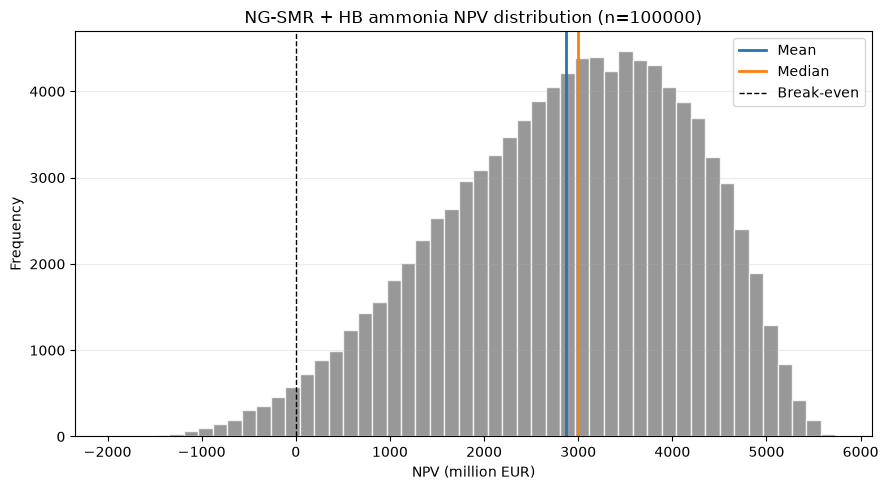

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"NG-SMR + HB ammonia NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

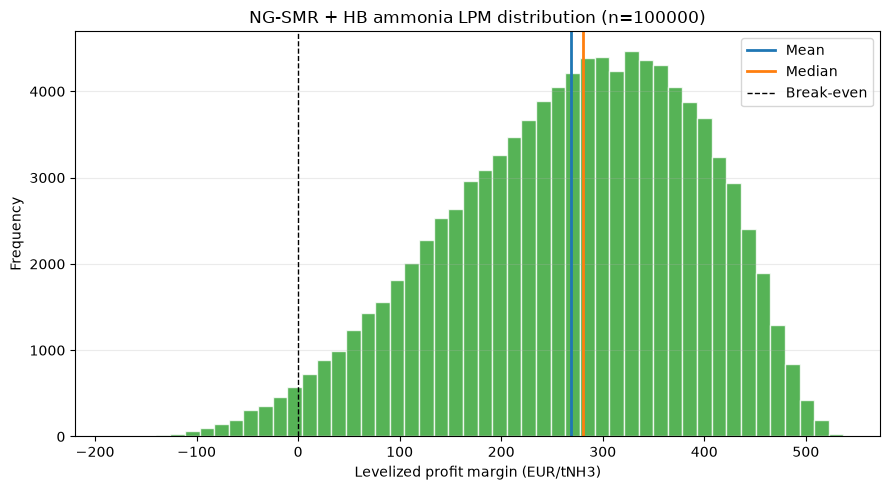

In [5]:
plot_financial_metric_distribution(
    levelized_profit_margin_eur_per_tnh3,
    title=f"NG-SMR + HB ammonia LPM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized profit margin (EUR/tNH3)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

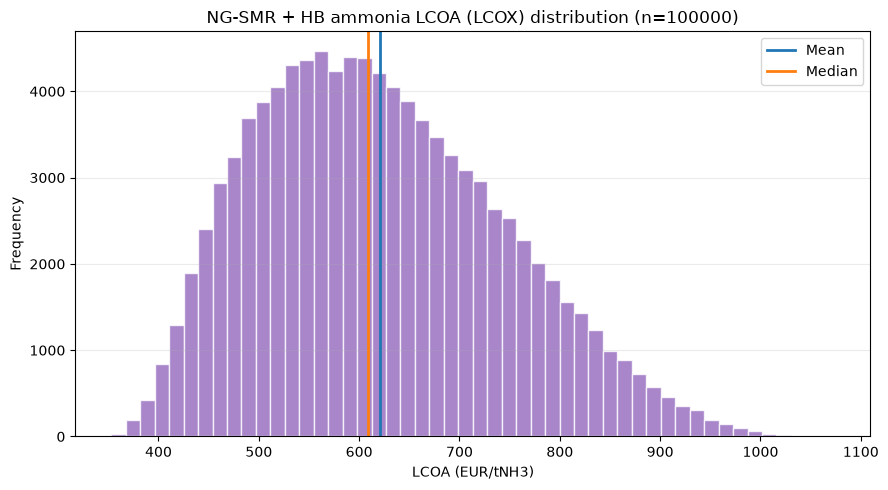

In [6]:
plot_financial_metric_distribution(
    lcoa_eur_per_tnh3,
    title=f"NG-SMR + HB ammonia LCOA (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOA (EUR/tNH3)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_coal_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                      890.000
annual_fixed_opex_eur                    29.399
annual_variable_opex_eur                  8.950
annual_natural_gas_cost_eur             332.755
annual_coal_cost_eur                      0.000
annual_biomass_cost_eur                   0.000
annual_fuel_cost_eur                    332.755
annual_electricity_cost_eur               0.000
annual_transport_and_storage_cost_eur     0.000
annual_emissions_cost_eur               138.397
annual_net_cash_flow_eur                380.499
Name: Mean annual value, million EUR, dtype: float64